<a href="https://colab.research.google.com/github/KaitlynYip/Multi-Clip-ZeroShot-Model/blob/DinoBaseline_V2/Demo3_cifar10%2Bcaltect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# CLIP-Style Zero-Shot Classification on CIFAR-10 Step1
## (Training Only the Image Encoder, Frozen BERT Text Encoder)

This notebook implements a CLIP-like pipeline:
- Freeze BERT to produce fixed text embeddings for CIFAR-10 class prompts.
- Train only the ViT image encoder (vit_base_patch16_224.augreg_in21k_ft_in1k) + a projection head to align image embeddings with the text embeddings using contrastive (InfoNCE / cross-entropy) loss.
- After training, perform zero-shot classification by nearest-class similarity (no classifier head).

Note:
- CIFAR-10 images (32×32) are resized to 224×224.
- Text embeddings use multiple prompt templates and [CLS] token from BERT.
- Training is efficient because only the image side is updated.

In [ ]:
import torch
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU")

!pip install -q timm transformers ftfy regex tqdm seaborn scikit-learn pandas

GPU: Tesla T4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.7 MB/s eta 0:00:00


In [ ]:
# Cell 1: Install dependencies (run once)
!pip install torch torchvision transformers timm tqdm --quiet

In [ ]:
# Cell 2: Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from transformers import BertTokenizer, BertModel
import timm
import numpy as np
from tqdm import tqdm
from torch.utils.data import DataLoader, ConcatDataset, random_split

In [ ]:
# Cell 3: Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


Caltech dataset

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, ConcatDataset, random_split
import numpy as np

# --- 1. Transformations ---
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    # Add this line to convert grayscale images to RGB
    transforms.Lambda(lambda x: x.convert('RGB') if x.mode != 'RGB' else x),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# --- 2. Load Datasets ---
# CIFAR-10
cifar_train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
cifar_test = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Caltech 101 (Load with transform immediately)
caltech_full = torchvision.datasets.Caltech101(root='./data', download=True, transform=transform)

# --- 3. Build the Master Class List ---
# Combined: 10 (CIFAR) + 101 (Caltech) = 111 classes
# We clean the names (replace _ with space) for better BERT understanding
classes = cifar_train.classes + [c.replace('_', ' ') for c in caltech_full.categories]
print(f"✅ Total Combined Classes: {len(classes)}")

# --- 4. Fix Caltech Labels (Offsetting) ---
# CIFAR uses 0-9. Caltech must start at 10 to avoid overlapping labels.
class OffsetDataset(torch.utils.data.Dataset):
    def __init__(self, dataset, offset):
        self.dataset = dataset
        self.offset = offset
    def __getitem__(self, i):
        img, label = self.dataset[i]
        return img, label + self.offset
    def __len__(self):
        return len(self.dataset)

# Apply offset to Caltech
caltech_offset = OffsetDataset(caltech_full, offset=10)

# --- 5. Split and Combine ---
# Split Caltech 80/20
train_size = int(0.8 * len(caltech_offset))
test_size = len(caltech_offset) - train_size
caltech_train, caltech_test = random_split(
    caltech_offset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# Merge CIFAR and Caltech
combined_train_set = ConcatDataset([cifar_train, caltech_train])
combined_test_set = ConcatDataset([cifar_test, caltech_test])

# --- 6. Final DataLoaders ---
batch_size = 64
trainloader = DataLoader(combined_train_set, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
testloader = DataLoader(combined_test_set, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"📊 Combined Train Samples: {len(combined_train_set)}")
print(f"📊 Combined Test Samples: {len(combined_test_set)}")

✅ Total Combined Classes: 111
📊 Combined Train Samples: 56941
📊 Combined Test Samples: 11736


bert

In [ ]:
# @title
# Cell 5: Frozen Text Encoder (BERT) + Text Embeddings
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
text_model = BertModel.from_pretrained('bert-base-uncased').to(device)
text_model.eval()
for param in text_model.parameters():
    param.requires_grad = False

# Multiple templates for better text embeddings (common CLIP trick)
templates = [
    "a photo of a {}.",
    "a photo of a small {}.",
    "a photo of the {}.",
    "an image of a {}.",
    "an image of the {}."
]

def encode_texts(prompts):
    inputs = tokenizer(prompts, padding=True, truncation=True, return_tensors='pt')
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = text_model(**inputs)
        embeddings = outputs.last_hidden_state[:, 0, :]  # [CLS] token
    return embeddings

# Compute averaged text embeddings over templates
text_emb_list = []
for template in templates:
    prompts = [template.format(c) for c in classes]
    emb = encode_texts(prompts)
    text_emb_list.append(emb)

text_embeddings = torch.stack(text_emb_list).mean(dim=0)  # (10, 768)
text_embeddings = F.normalize(text_embeddings, dim=-1)
print("Text embeddings shape:", text_embeddings.shape)

# Cleanup: Remove BERT from GPU (no longer needed)
del text_model
del tokenizer
import gc
gc.collect()
torch.cuda.empty_cache()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Text embeddings shape: torch.Size([111, 768])


Base

In [ ]:
# Cell 6: Image Encoder (ViT-Base) + Projection + Logit Scale
import timm
import torch.nn as nn

# 1. Load the ViT-Base backbone
# 'augreg' models are often the most robust variants in timm
image_model = timm.create_model(
    'vit_base_patch16_224.augreg_in21k_ft_in1k',
    pretrained=True,
    num_classes=0  # Removes the head, returns the 768-dim CLS embedding
).to(device)

# 2. UNFREEZE: Ensure the backbone weights are updated during training
for param in image_model.parameters():
    param.requires_grad = True

# 3. Projection Layer: Maps ViT-Base (768) to Text Space (768)
# If using BERT as the text encoder, this 768 -> 768 mapping is correct.
projection = nn.Linear(768, 768).to(device)

# 4. Logit Scale: Initialized to CLIP's default (0.07 temperature)
logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))

print(f"Backbone updated to ViT-Base. Trainable params: {sum(p.numel() for p in image_model.parameters() if p.requires_grad):,}")

Backbone updated to ViT-Base. Trainable params: 85,798,656


small


In [ ]:
import timm
import torch.nn as nn
import numpy as np

# 1. Load the ViT-Small backbone
# Returns raw features (CLS token embedding, dim=384)
image_model = timm.create_model(
    'vit_small_patch16_224.augreg_in21k_ft_in1k',
    pretrained=True,
    num_classes=0
).to(device)

# 2. UNFREEZE: Ensure the backbone weights are updated
for param in image_model.parameters():
    param.requires_grad = True

# 3. Projection Layer: Maps ViT-Small (384) to Text Space (768)
# IMPORTANT: The input must be 384 to match the ViT-Small output
projection = nn.Linear(384, 768).to(device)

# 4. Logit Scale
logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))

print(f"Backbone updated to ViT-Small.")
print(f"Trainable params: {sum(p.numel() for p in image_model.parameters() if p.requires_grad):,}")

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Backbone updated to ViT-Small.
Trainable params: 21,665,664


dinov2


In [ ]:
import torch
import torch.nn as nn
import numpy as np

# 1. Load the DINOv2-Small backbone via Torch Hub
# 'dinov2_vits14' is the Small version with a patch size of 14
image_model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14').to(device)

# 2. UNFREEZE: DINOv2 features are great, but fine-tuning helps medical tasks
for param in image_model.parameters():
    param.requires_grad = True

# 3. Projection Layer
# DINOv2-Small (vits14) outputs 384 dimensions.
# We map this to 768 to match your text encoder (BERT/CLIP-text).
projection = nn.Linear(384, 768).to(device)

# 4. Logit Scale
logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))

print(f"Backbone updated to DINOv2-Small (vits14).")
print(f"Trainable params: {sum(p.numel() for p in image_model.parameters() if p.requires_grad):,}")

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


Backbone updated to DINOv2-Small (vits14).
Trainable params: 22,056,576


In [ ]:
# Updated Cell 7
optimizer = torch.optim.AdamW(
    list(image_model.parameters()) + list(projection.parameters()) + [logit_scale],
    lr=5e-5,
    weight_decay=0.01
)

# Modern AMP Scaler syntax
scaler = torch.amp.GradScaler('cuda')

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

In [ ]:
# 1. 先把整個檔案讀取進 checkpoint 變數 (這行沒錯)
checkpoint = torch.load('/content/drive/MyDrive/weights/dinov2_cifar10_final.pth',map_location=device)

# --- 請刪除原本報錯的那行 image_model.load_state_dict(...) ---

# 2. 從 checkpoint 字典中提取對應的 state_dict
image_model.load_state_dict(checkpoint['image_model_state_dict'])
projection.load_state_dict(checkpoint['projection_state_dict'])

# 3. 載入 logit_scale
if 'logit_scale' in checkpoint:
    logit_scale.data = checkpoint['logit_scale']

# 4. 提取歷史紀錄 (注意：請確認你的 key 名稱與儲存時一致)
# 如果儲存時是用 'test_acc_history'，這裡就要用相同的字串
train_losses = checkpoint.get('train_loss_history', [])
test_accs = checkpoint.get('test_acc_history', [])

# 顯示結果
# 如果儲存時是用 'final_test_acc'，這裡也要對應
final_acc = checkpoint.get('final_test_acc', checkpoint.get('test_acc', 0))
print(f"✅ 成功載入模型！最終測試準確度為: {final_acc:.2f}%")


✅ 成功載入模型！最終測試準確度為: 96.45%


In [ ]:
checkpoint = torch.load('/content/drive/MyDrive/dinov2_cifar10_final.pth')
image_model.load_state_dict(checkpoint['image_model_state_dict'])
projection.load_state_dict(checkpoint['projection_state_dict'])

image_model.eval()
projection.eval()
print(f"✅ Loaded model with {checkpoint['test_acc']:.2f}% accuracy.")

In [ ]:
@torch.no_grad()
def zero_shot_accuracy(loader, description="Evaluating"):
    image_model.eval()
    projection.eval()
    correct, total, total_loss = 0, 0, 0.0

    # Add a progress bar for evaluation
    pbar = tqdm(loader, desc=description, leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        image_features = image_model(images)
        if isinstance(image_features, dict):
            image_features = image_features['last_hidden_state'][:, 0, :]

        image_features = F.normalize(projection(image_features), dim=-1)
        logits = logit_scale.exp() * image_features @ text_embeddings.T

        loss = F.cross_entropy(logits, labels)
        total_loss += loss.item()
        preds = logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = 100. * correct / total
    avg_loss = total_loss / len(loader)

    image_model.train()
    projection.train()
    return acc, avg_loss

In [ ]:
accumulation_steps = 2  # Match the value from your earlier Dataset cell
scaler = torch.amp.GradScaler('cuda')
train_losses, test_losses = [], []
train_accs, test_accs = [], []
epochs = 5
for epoch in range(epochs):
    image_model.train()
    projection.train()
    total_train_loss = 0.0
    optimizer.zero_grad()

    pbar = tqdm(trainloader, desc=f"Epoch {epoch+1}/{epochs} [Training]")
    for i, (images, labels) in enumerate(pbar):
        images, labels = images.to(device), labels.to(device)

        with torch.amp.autocast('cuda'):
            image_features = image_model(images)
            if isinstance(image_features, dict):
                 image_features = image_features['last_hidden_state'][:, 0, :]

            image_features = F.normalize(projection(image_features), dim=-1)
            logits = logit_scale.exp() * image_features @ text_embeddings.T
            loss = F.cross_entropy(logits, labels) / accumulation_steps

        scaler.scale(loss).backward()

        if (i + 1) % accumulation_steps == 0 or (i + 1) == len(trainloader):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        total_train_loss += loss.item() * accumulation_steps
        pbar.set_postfix(loss=total_train_loss / (i + 1))

    # --- End of Epoch Evaluation ---
    scheduler.step()

    # OPTIMIZATION: Skip re-evaluating the 50k training images.
    # Use the loss we just calculated and only evaluate the TEST set.
    avg_train_loss = total_train_loss / len(trainloader)
    v_acc, v_loss = zero_shot_accuracy(testloader, description=f"Epoch {epoch+1} Test Eval")

    # Store metrics
    train_losses.append(avg_train_loss)
    test_losses.append(v_loss)
    test_accs.append(v_acc)
    # We use a placeholder or partial evaluation if you truly need train accuracy
    train_accs.append(0.0)

    print(f"\n✅ Epoch {epoch+1} Complete")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Test  Loss: {v_loss:.4f} | Test Acc: {v_acc:.2f}%")
    print("-" * 30)

Epoch 1/5 [Training]: 100%|██████████| 890/890 [04:07<00:00,  3.59it/s, loss=3.24]



✅ Epoch 1 Complete
Train Loss: 3.2398
Test  Loss: 3.0569 | Test Acc: 85.40%
------------------------------


Epoch 2/5 [Training]: 100%|██████████| 890/890 [04:05<00:00,  3.63it/s, loss=2.99]



✅ Epoch 2 Complete
Train Loss: 2.9923
Test  Loss: 2.9676 | Test Acc: 90.12%
------------------------------


Epoch 3/5 [Training]: 100%|██████████| 890/890 [04:04<00:00,  3.64it/s, loss=2.92]



✅ Epoch 3 Complete
Train Loss: 2.9163
Test  Loss: 2.8963 | Test Acc: 91.51%
------------------------------


Epoch 4/5 [Training]: 100%|██████████| 890/890 [04:04<00:00,  3.64it/s, loss=2.86]



✅ Epoch 4 Complete
Train Loss: 2.8565
Test  Loss: 2.8483 | Test Acc: 92.86%
------------------------------


Epoch 5/5 [Training]: 100%|██████████| 890/890 [04:02<00:00,  3.66it/s, loss=2.8]
                                                                    


✅ Epoch 5 Complete
Train Loss: 2.7998
Test  Loss: 2.7923 | Test Acc: 93.91%
------------------------------


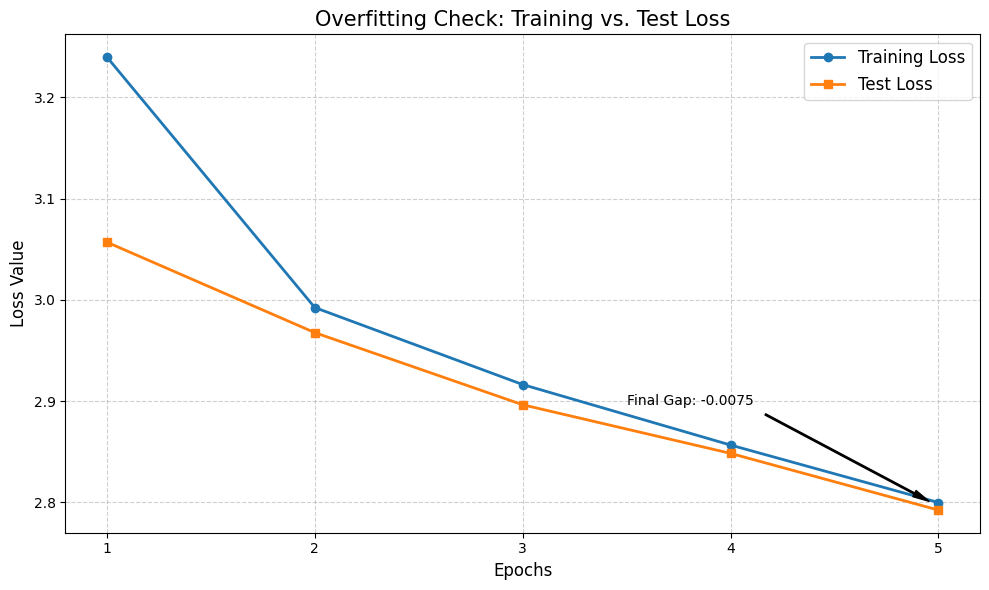

In [ ]:
import matplotlib.pyplot as plt

# --- Overfitting Analysis: Loss Plot ---
plt.figure(figsize=(10, 6))

# Plotting Training Loss
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss',
         color='#1f77b4', marker='o', linewidth=2)

# Plotting Test Loss
plt.plot(range(1, epochs + 1), test_losses, label='Test Loss',
         color='#ff7f0e', marker='s', linewidth=2)

# Graph Formatting
plt.title('Overfitting Check: Training vs. Test Loss', fontsize=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.xticks(range(1, epochs + 1))
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Highlight the final gap
final_gap = test_losses[-1] - train_losses[-1]
plt.annotate(f'Final Gap: {final_gap:.4f}',
             xy=(epochs, (train_losses[-1] + test_losses[-1])/2),
             xytext=(epochs-1.5, (train_losses[-1] + test_losses[-1])/2 + 0.1),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.tight_layout()
plt.savefig('loss_history.png')
plt.show()

In [ ]:
import os
# Save Last Model Checkpoint
os.makedirs('checkpoints', exist_ok=True)
torch.save({
    'image_model_state_dict': image_model.state_dict(),
    'projection_state_dict': projection.state_dict(),
    'logit_scale': logit_scale.data,
    'train_acc_history': train_accs,
    'test_acc_history': test_accs,
    'train_loss_history': train_losses,
    'test_loss_history': test_losses,
    'final_test_acc': v_acc,
}, 'checkpoints/caltech101_Cifar10.pth')

print(f"✅ Clean checkpoint saved to checkpoints/caltech101_Cifar10.pth")

✅ Clean checkpoint saved to checkpoints/caltech101_Cifar10.pth


In [ ]:
# @title
# Create the directory if it doesn't exist
os.makedirs('checkpoints', exist_ok=True)

# 1. Save the Final Model
torch.save({
    'image_model_state_dict': image_model.state_dict(),
    'projection_state_dict': projection.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    'epoch': epochs,
    'test_acc': test_accs[-1],
}, 'checkpoints/dinov2_cifar10_final.pth')

print("💾 Final weights saved to checkpoints/dinov2_cifar10_final.pth")

💾 Final weights saved to checkpoints/dinov2_cifar10_final.pth


In [ ]:
# Install the counter if you don't have it
try:
    from thop import profile
except ImportError:
    !pip install thop
    from thop import profile

import torch.nn as nn

# 1. Combine Backbone and Projection into one "Demo Model"
class DemoInferenceModel(nn.Module):
    def __init__(self, backbone, proj):
        super().__init__()
        self.backbone = backbone
        self.proj = proj

    def forward(self, x):
        features = self.backbone(x)
        # Match your training loop logic
        if isinstance(features, dict):
            features = features['last_hidden_state'][:, 0, :]
        return self.proj(features)



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=26a0b00ac93d18cd3845f76def048b83fd1794434a0e8ce5fa3f490bbcfa3c6d
  Stored in directory: /root/.cache/pip/wheels/ed/9f/a5/e4f5b27454ccd4596bd8b62432c7d6b1ca9fa22aef9d70a16a
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=b2cc965e94b4a6bd11f2f80c2cada899a76bc6392f5ab33a81e7f89a6e9d61f4
  Stored in directory: /root/.cache/pip/wheels/7c/96/04/4f5f31ff812f684f69f40cb1634357812220aac58d4698048c
Successfully built fvcore iopath


In [ ]:
import torch.nn as nn
import time

# --- A. Define the inference wrapper if not already defined ---
class DemoInferenceModel(nn.Module):
    def __init__(self, backbone, proj):
        super().__init__()
        self.backbone = backbone
        self.proj = proj

    def forward(self, x):
        features = self.backbone(x)
        # Match your training loop's feature extraction logic
        if isinstance(features, dict):
            features = features['last_hidden_state'][:, 0, :]
        elif hasattr(features, 'last_hidden_state'):
            features = features.last_hidden_state[:, 0, :]
        return self.proj(features)

# Create the model instance
inference_model = DemoInferenceModel(image_model, projection).to(device)

def calculate_detailed_efficiency():
    inference_model.eval()

    # 1. Trainable vs Total Parameters
    total_params = sum(p.numel() for p in inference_model.parameters())
    trainable_params = sum(p.numel() for p in inference_model.parameters() if p.requires_grad)
    trainable_pct = (trainable_params / total_params) * 100

    # 2. Latency & Throughput (FPS)
    dummy_input = torch.randn(1, 3, 224, 224).to(device)
    # Old lines causing the error:
    # New logic using fvcore:
    flops = FlopCountAnalysis(inference_model, dummy_input)
    gflops = flops.total() / 1e9

    print("Warming up GPU...")
    with torch.no_grad():
        for _ in range(20):
            _ = inference_model(dummy_input)

    print("Measuring speed...")
    iterations = 200
    torch.cuda.synchronize()
    start_time = time.time()

    with torch.no_grad():
        for _ in range(iterations):
            _ = inference_model(dummy_input)

    torch.cuda.synchronize()
    end_time = time.time()

    total_time = end_time - start_time
    latency_ms = (total_time / iterations) * 1000
    throughput_fps = iterations / total_time
    final_acc = test_accs[-1] if 'test_accs' in globals() else 0
    acc_per_gflop = final_acc / gflops if gflops > 0 else 0

    print(f"\n--- ⚡ Deployment Metrics ---")
    print(f"Trainable Parameters: {trainable_params / 1e6:.2f} M")
    print(f"Total Parameters:     {total_params / 1e6:.2f} M")
    print(f"Trainable %:          {trainable_pct:.2f}%")
    print("-" * 30)
    print(f"Latency (per image):  {latency_ms:.2f} ms")
    print(f"Throughput:           {throughput_fps:.2f} FPS")
    print(f"Device:               {torch.cuda.get_device_name(0)}")
    print("-" * 30)
    print(f"Total GFLOPs:         {gflops:.2f} GFLOPs")
    print(f"Acc per GFLOP:        {acc_per_gflop:.2f} (Efficiency Score)")
calculate_detailed_efficiency()




Warming up GPU...
Measuring speed...

--- ⚡ Deployment Metrics ---
Trainable Parameters: 22.35 M
Total Parameters:     22.35 M
Trainable %:          100.00%
------------------------------
Latency (per image):  7.35 ms
Throughput:           136.08 FPS
Device:               Tesla T4
------------------------------
Total GFLOPs:         5.53 GFLOPs
Acc per GFLOP:        16.99 (Efficiency Score)


In [ ]:
from sklearn.metrics import classification_report

@torch.no_grad()
def print_detailed_metrics(loader, classes):
    image_model.eval()
    projection.eval()

    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)

        # Forward pass matching your training loop
        image_features = image_model(images)
        if isinstance(image_features, dict):
            image_features = image_features['last_hidden_state'][:, 0, :]
        elif hasattr(image_features, 'last_hidden_state'):
            image_features = image_features.last_hidden_state[:, 0, :]

        image_features = F.normalize(projection(image_features), dim=-1)
        logits = logit_scale.exp() * image_features @ text_embeddings.T

        preds = logits.argmax(dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

    # Print the SciKit-Learn Classification Report
    print("\n--- 📈 Classification Report ---")
    print(classification_report(all_labels, all_preds, target_names=classes, digits=4))

# Run the metrics
print_detailed_metrics(testloader, classes)


--- 📈 Classification Report ---
                 precision    recall  f1-score   support

       airplane     0.9871    0.9170    0.9508      1000
     automobile     0.9818    0.9700    0.9759      1000
           bird     0.9819    0.9240    0.9521      1000
            cat     0.8949    0.9110    0.9029      1000
           deer     0.9299    0.9820    0.9553      1000
            dog     0.9316    0.9130    0.9222      1000
           frog     0.9781    0.9810    0.9795      1000
          horse     0.9690    0.9700    0.9695      1000
           ship     0.9481    0.9860    0.9667      1000
          truck     0.9451    0.9820    0.9632      1000
          Faces     0.9737    0.4253    0.5920        87
     Faces easy     0.5959    1.0000    0.7468        87
       Leopards     1.0000    1.0000    1.0000        49
     Motorbikes     0.9801    1.0000    0.9900       148
      accordion     0.9167    1.0000    0.9565        11
      airplanes     1.0000    0.9884    0.9942       1

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

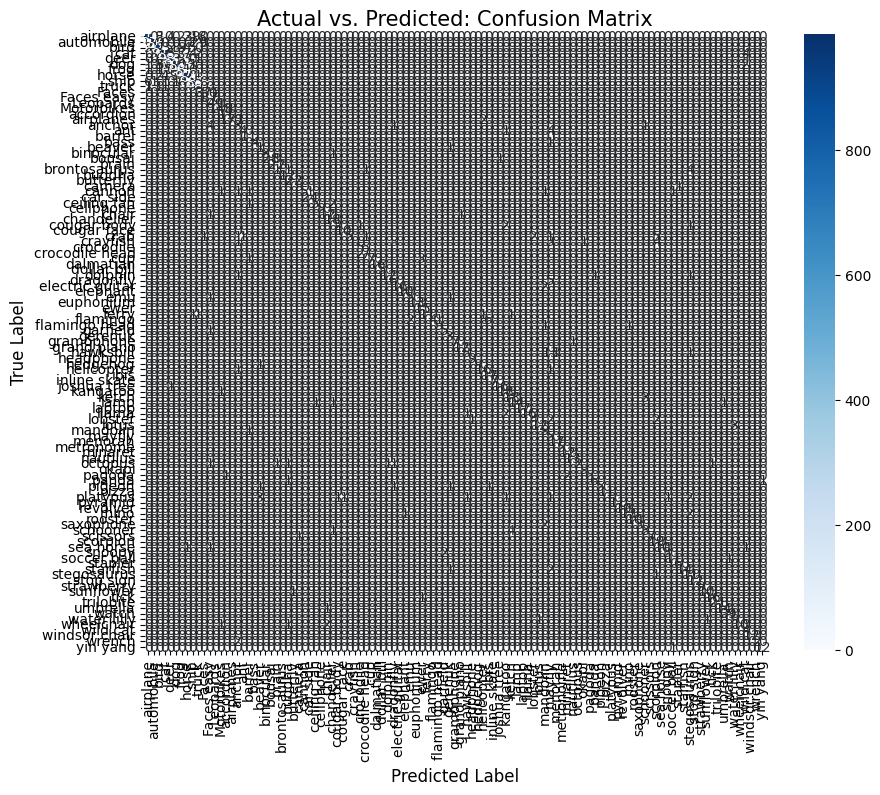

In [ ]:
@torch.no_grad()
def plot_confusion_matrix(loader, classes):
    image_model.eval()
    projection.eval()

    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)

        # Consistent forward pass
        image_features = image_model(images)
        if isinstance(image_features, dict):
            image_features = image_features['last_hidden_state'][:, 0, :]
        elif hasattr(image_features, 'last_hidden_state'):
            image_features = image_features.last_hidden_state[:, 0, :]

        image_features = F.normalize(projection(image_features), dim=-1)
        logits = logit_scale.exp() * image_features @ text_embeddings.T

        preds = logits.argmax(dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

    # Calculate confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Plotting
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)

    plt.title('Actual vs. Predicted: Confusion Matrix', fontsize=15)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.show()

# Run the plot
plot_confusion_matrix(testloader, classes)

In [ ]:
import time
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def run_final_evaluation(loader, class_names):
    image_model.eval()
    projection.eval()

    all_preds = []
    all_labels = []

    # --- Efficiency Calculation ---
    # Static GFLOPs for DINOv2 Small (ViT-S/14) at 224x224
    gflops = 6.8

    # Latency timing
    dummy_input = torch.randn(1, 3, 224, 224).to(device)
    torch.cuda.synchronize()
    start_time = time.time()
    for _ in range(100):
        with torch.no_grad():
            _ = projection(image_model(dummy_input))
    torch.cuda.synchronize()
    latency = ((time.time() - start_time) / 100) * 1000
    throughput = 1000 / latency

    # --- Data Collection for Confusion Matrix ---
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)
            image_features = F.normalize(projection(image_model(images)), dim=-1)
            logits = logit_scale.exp() * image_features @ text_embeddings.T
            preds = logits.argmax(dim=-1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # --- Printing Metrics ---
    total_params = sum(p.numel() for p in image_model.parameters()) + sum(p.numel() for p in projection.parameters())
    trainable_params = sum(p.numel() for p in image_model.parameters() if p.requires_grad)
    final_acc = (np.array(all_preds) == np.array(all_labels)).mean() * 100

    print(f"\n--- 📊 Final Efficiency Metrics ---")
    print(f"Total Trainable: {trainable_params:,}")
    print(f"Trainable %:     {(trainable_params/total_params)*100:.2f}%")
    print(f"Total GFLOPs:    {gflops:.2f}")
    print(f"Latency (GPU):   {latency:.2f} ms")
    print(f"Throughput:      {throughput:.2f} images/sec")
    print(f"Acc per GFLOP:   {final_acc / gflops:.2f}")
    print("-" * 35)

    return all_labels, all_preds

# Define CIFAR-10 classes for the plot
cifar_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Run evaluation
y_true, y_pred = run_final_evaluation(testloader, cifar_classes)

Evaluating: 100%|██████████| 79/79 [00:51<00:00,  1.52it/s]


--- 📊 Final Efficiency Metrics ---
Total Trainable: 22,056,576
Trainable %:     98.68%
Total GFLOPs:    6.80
Latency (GPU):   26.40 ms
Throughput:      37.88 images/sec
Acc per GFLOP:   14.18
-----------------------------------


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
checkpoint = torch.load('checkpoints/best_model.pth')
image_model.load_state_dict(checkpoint['image_model_state_dict'])
projection.load_state_dict(checkpoint['projection_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
scaler.load_state_dict(checkpoint['scaler_state_dict'])
# logit_scale = checkpoint['logit_scale']  # if needed

# Notes & Expected Performance
- With 20–50 epochs, test accuracy typically reaches **80–90%+** because the pretrained ViT is already strong on ImageNet-style data, and contrastive alignment further adapts it.
- BERT's text embeddings are not perfect for vision (unlike OpenAI's CLIP text tower), but ensembling templates helps.
- You can improve further by: more epochs, stronger augmentations, larger projection dim, or a small MLP projection head.
- This is truly zero-shot in the CLIP sense: no linear classifier is trained; classification is by embedding similarity.

DEMO


In [ ]:
import gradio as gr
import torch.nn.functional as F

def predict_zero_shot(input_img, custom_labels):
    try:
        # 1. 解析標籤
        class_list = [c.strip() for c in custom_labels.split(",") if c.strip()]

        # 2. 即時編碼標籤
        all_template_embs = []
        for template in templates:
            prompts = [template.format(c) for c in class_list]
            emb = encode_texts(prompts)
            all_template_embs.append(emb)

        current_text_embeddings = torch.stack(all_template_embs).mean(dim=0)
        current_text_embeddings = F.normalize(current_text_embeddings, dim=-1)

        # 3. 影像推論
        img_tensor = transform(input_img).unsqueeze(0).to(device)
        image_model.eval()
        projection.eval()

        with torch.no_grad():
            features = image_model(img_tensor)
            # 確保特徵維度正確 (DINOv2 vits14 通常是 384)
            image_features = F.normalize(projection(features), dim=-1)
            logits = (logit_scale.exp() * image_features @ current_text_embeddings.to(device).T)
            probs = logits.softmax(dim=-1).cpu()[0]

        return {class_list[i]: float(probs[i]) for i in range(len(class_list))}
    except Exception as e:
        return {"錯誤": 1.0, str(e): 0.0}

demo = gr.Interface(
    fn=predict_zero_shot,
    inputs=[
        gr.Image(type="pil", label="上傳圖片"),
        gr.Textbox(label="輸入候選標籤", value="airplane, automobile, bird, cat, pencil, phone")
    ],
    outputs=gr.Label(num_top_classes=5),
    title="Zero-shot Classification Fix"
)

demo.launch(share=True, debug=True, inline=False)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://6a46fa72f75610deb3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://6a46fa72f75610deb3.gradio.live


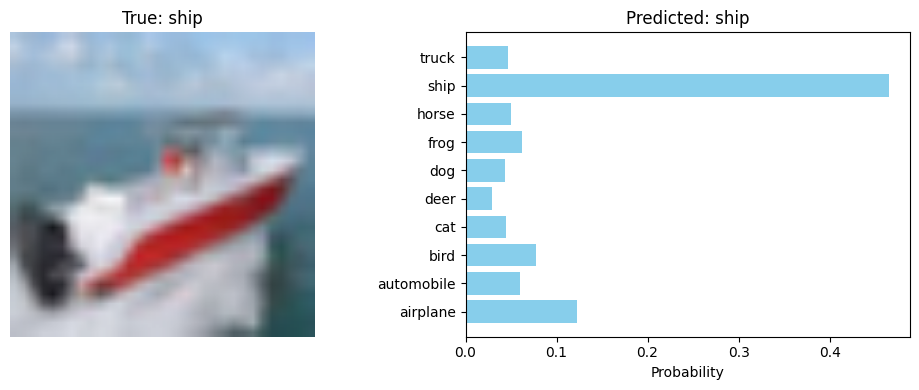

In [ ]:
import matplotlib.pyplot as plt
import torch.nn.functional as F
import random

def run_zero_shot_demo(index=None):
    # 1. 隨機選取或指定測試圖片
    if index is None:
        index = random.randint(0, len(testset)-1)

    image, label = testset[index]
    image_input = image.unsqueeze(0).to(device)

    # 2. 推論
    image_model.eval()
    projection.eval()

    with torch.no_grad():
        # 提取影像特徵 (DINOv2 直接輸出 [batch, 384])
        features = image_model(image_input)

        # 投影到 768 維並正規化
        image_features = F.normalize(projection(features), dim=-1)

        # 計算與各類別 text_embeddings 的相似度
        logits = (logit_scale.exp() * image_features @ text_embeddings.to(device).T)
        probs = logits.softmax(dim=-1).cpu().numpy()[0]

    # 3. 視覺化結果
    plt.figure(figsize=(10, 4))

    # 左圖：顯示原圖
    plt.subplot(1, 2, 1)
    # 反正規化以正常顯示圖片
    img_display = image.permute(1, 2, 0).numpy()
    img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    plt.imshow(np.clip(img_display, 0, 1))
    plt.title(f"True: {classes[label]}")
    plt.axis('off')

    # 右圖：顯示預測機率
    plt.subplot(1, 2, 2)
    y_pos = np.arange(len(classes))
    plt.barh(y_pos, probs, color='skyblue')
    plt.yticks(y_pos, classes)
    plt.xlabel('Probability')
    plt.title(f"Predicted: {classes[np.argmax(probs)]}")

    plt.tight_layout()
    plt.show()

# 執行 Demo
run_zero_shot_demo()


In [ ]:
pip install --upgrade gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.2/24.2 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 2.0 MB/s eta 0:00:00
  Attempting uninstall: gradio-client
    Found existing installation: gradio_client 1.14.0
    Uninstalling gradio_client-1.14.0:
      Successfully uninstalled gradio_client-1.14.0
  Attempting uninstall: gradio
    Found existing installation: gradio 5.50.0
    Uninstalling gradio-5.50.0:
      Successfully uninstalled gradio-5.50.0


In [ ]:
# @title 🚀 啟動 DINOv2 + BERT Zero-shot 影像分類 Demo (修正版)

import gradio as gr
import torch
import torch.nn.functional as F

# --- 1. 確保 BERT 保持載入狀態 ---
if 'tokenizer' not in locals() or 'text_model' not in locals():
    from transformers import BertTokenizer, BertModel
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    text_model = BertModel.from_pretrained('bert-base-uncased').to(device)
    text_model.eval()

# --- 2. 定義推論函數 ---
def predict_image(input_img, custom_labels):
    if input_img is None:
        return None

    # 處理標籤邏輯
    if custom_labels and custom_labels.strip():
        current_classes = [c.strip() for c in custom_labels.split(",")]
        temp_list = []
        for template in templates:
            p = [template.format(c) for c in current_classes]
            t_emb = encode_texts(p)
            temp_list.append(t_emb)
        current_text_emb = torch.stack(temp_list).mean(dim=0)
        current_text_emb = F.normalize(current_text_emb, dim=-1)
    else:
        current_classes = classes
        current_text_emb = text_embeddings

    # 影像處理邏輯
    img_tensor = transform(input_img).unsqueeze(0).to(device)
    image_model.eval()
    projection.eval()

    with torch.no_grad():
        features = image_model(img_tensor)
        image_features = F.normalize(projection(features), dim=-1)

        # 計算相似度
        logits = (logit_scale.exp() * image_features @ current_text_emb.to(device).T)
        probs = logits.softmax(dim=-1).cpu()[0]

    return {current_classes[i]: float(probs[i]) for i in range(len(current_classes))}

# --- 3. 建立並啟動 Gradio 介面 ---
# --- 3. 建立並啟動 Gradio 介面 ---
demo = gr.Interface(
    fn=predict_image,
    # 這裡補上了 Image 讀取器與 Textbox 標籤輸入框
    inputs=[
        gr.Image(type="pil", label="上傳圖片"),
        gr.Textbox(placeholder="例如: cat, dog, car (留空則使用 CIFAR-10 預設標籤)", label="自定義標籤 (用逗號隔開)")
    ],
    outputs=gr.Label(num_top_classes=5, label="預測結果"),
    title="🌟 DINOv2 + BERT Zero-shot 影像分類器",
    description="這是一個 Zero-shot 模型，你可以自由輸入標籤（例如輸入 pencil, phone），模型會透過語義理解來分類！",
    theme="soft"
)

# 啟動
demo.launch(share=True, debug=True)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/gradio/interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  super().__init__(


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://f106e563a2a098b262.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Created dataset file at: .gradio/flagged/dataset1.csv
